In [6]:
from nmmlab.wilson_cowan import wilco_unforced, wilco_forced, wilco_network, sigmoid
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

In [13]:
#PARAMETERS 
tau_x = 8.0
tau_y = 8.0
w_xx  = 16.0
w_xy  = 12.0
w_yx  = 15.0
w_yy  = 3.0
x0    = [0.1, 0.05]
A     = 0.05
f     = 24.0

t      = np.linspace(0, 500, 50000)
t_long = np.linspace(0, 2000, 100000)
dt     = t_long[1] - t_long[0]

# network parameters
N   = 3
G   = 2.0
Px  = np.array([1.5, 1.5, 0.9])
rng = np.random.default_rng(42)
C = rng.random((N, N))
np.fill_diagonal(C, 0)
eigvals = np.linalg.eigvals(C)
C /= np.max(np.abs(eigvals))
x0_net = np.concatenate([rng.random(N) * 0.1, rng.random(N) * 0.05])
colors = ['blue', 'orange', 'green']


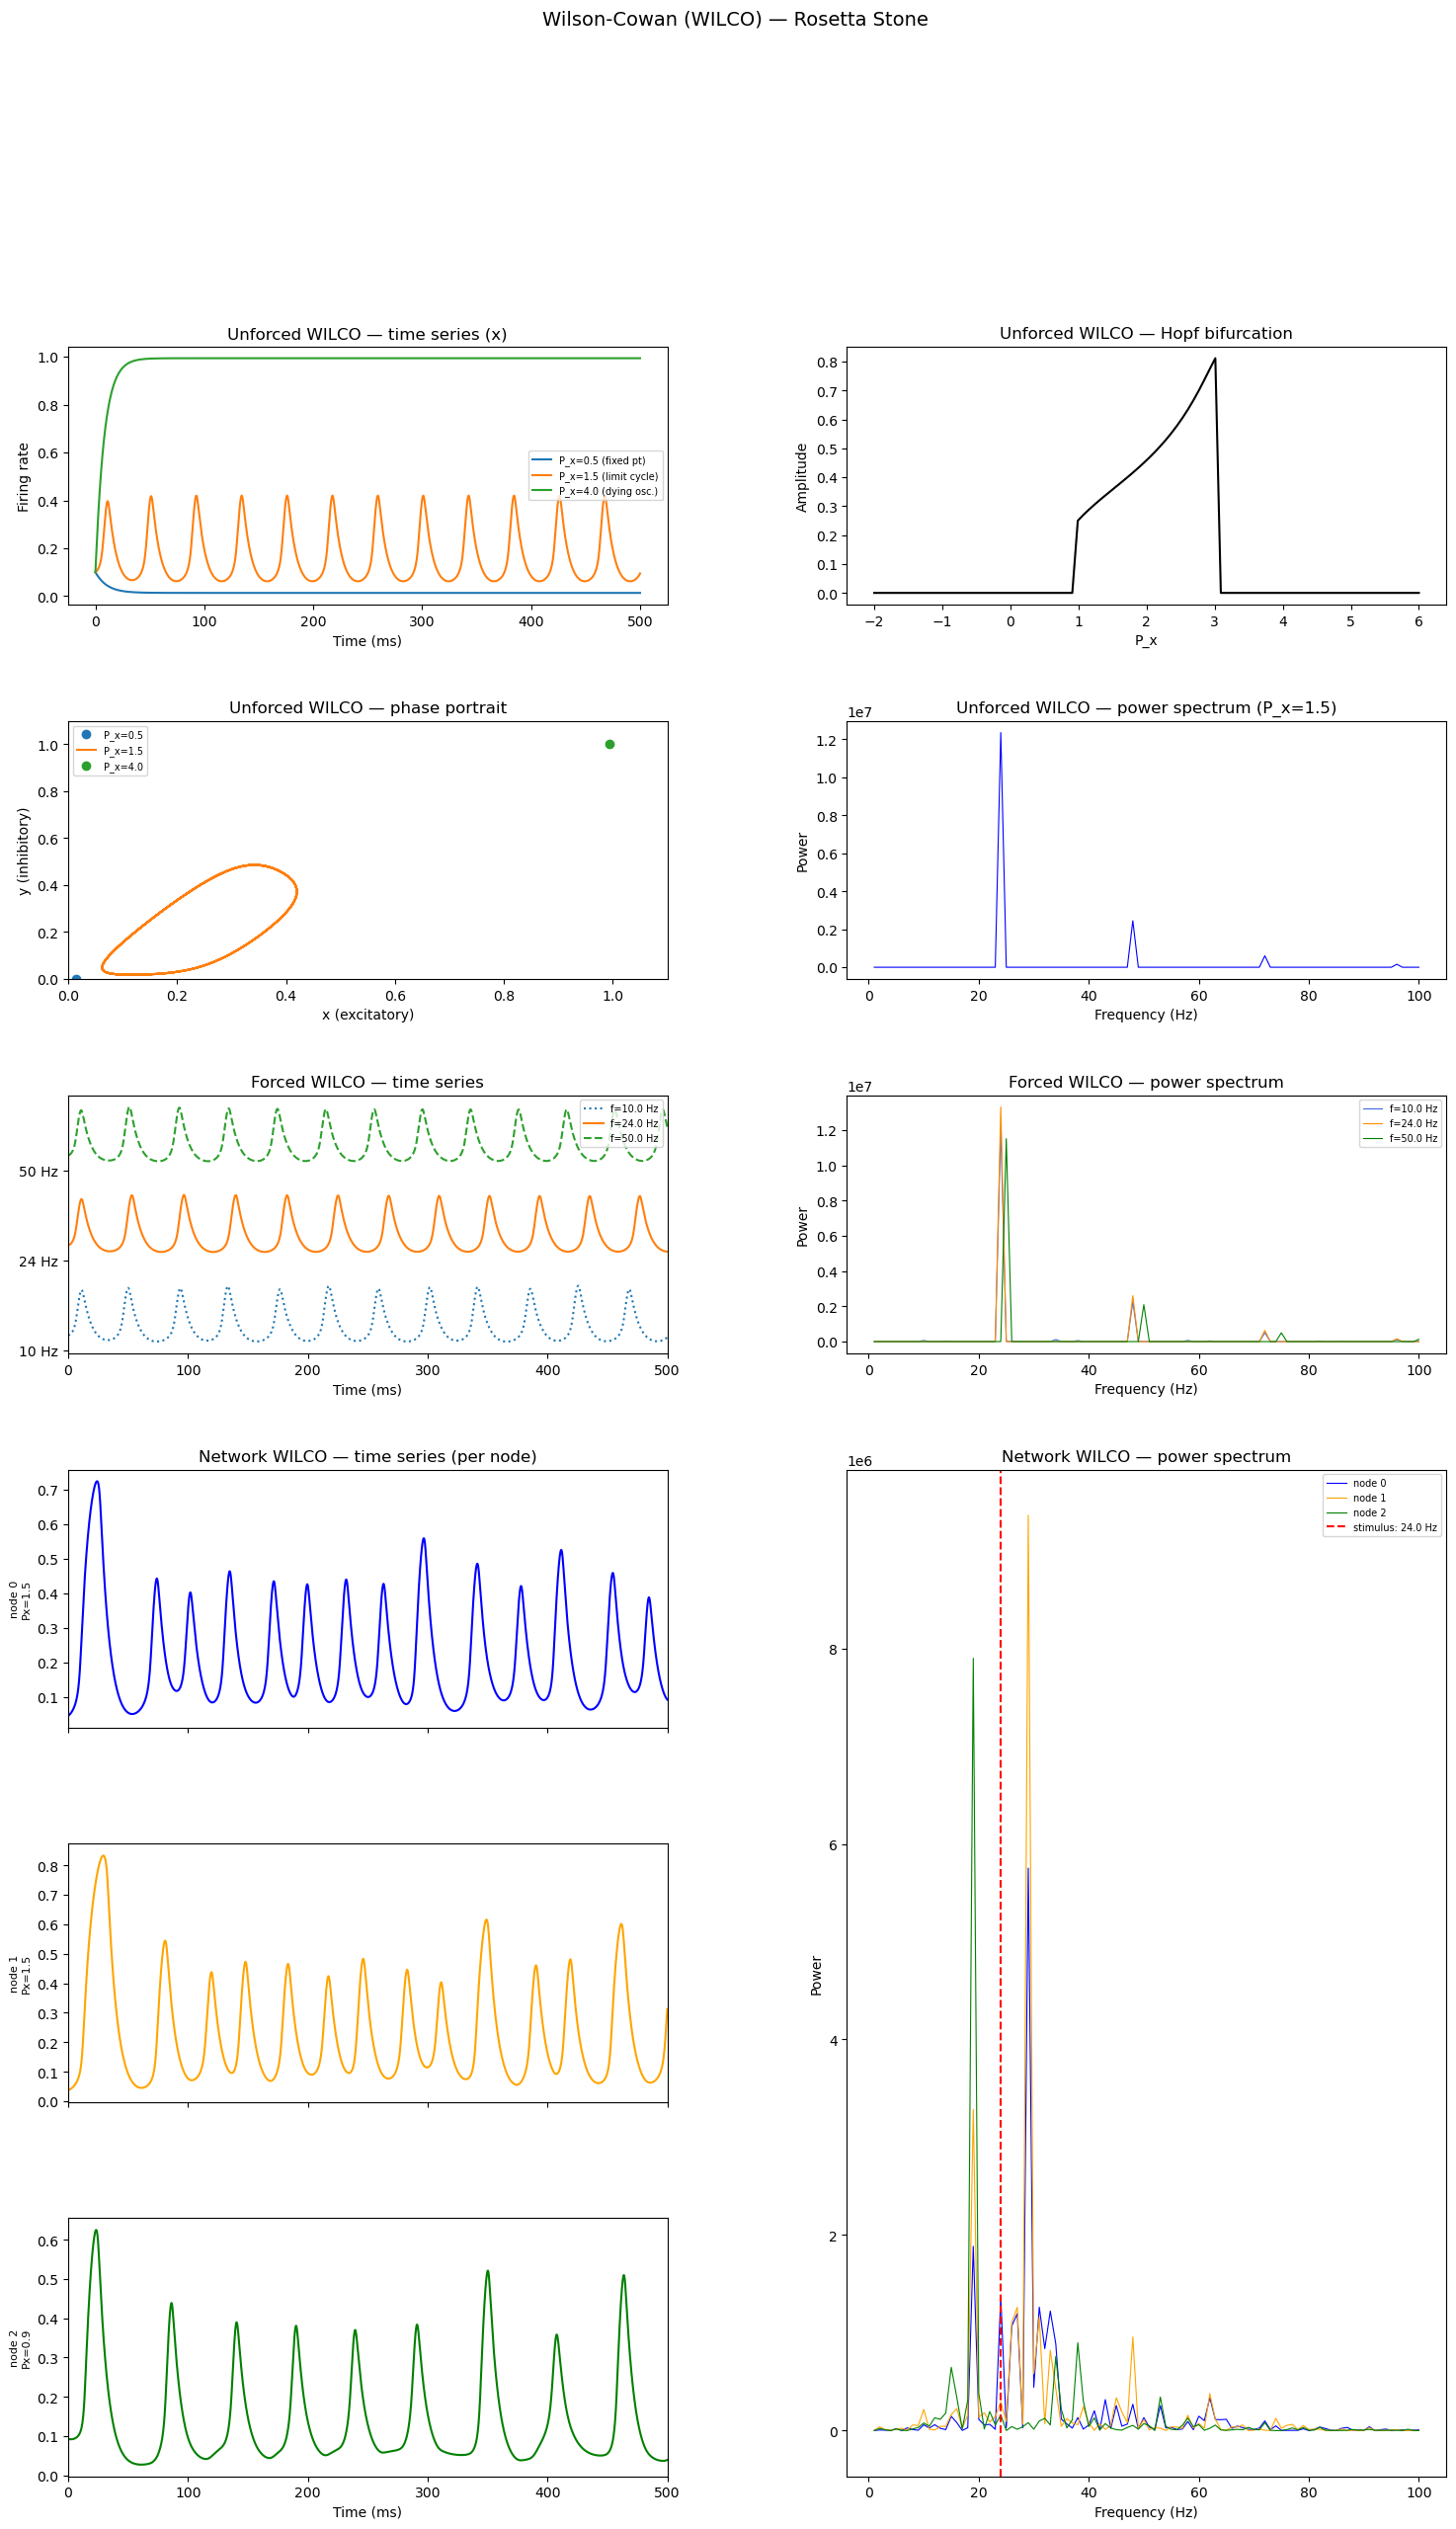

In [12]:
fig = plt.figure(figsize=(18, 28))
gs  = gridspec.GridSpec(6, 2, figure=fig, hspace=0.45, wspace=0.3)

ax1 = fig.add_subplot(gs[0, 0])   # unforced time series
ax2 = fig.add_subplot(gs[0, 1])   # bifurcation
ax3 = fig.add_subplot(gs[1, 0])   # phase portrait
ax4 = fig.add_subplot(gs[1, 1])   # power spectrum
ax5 = fig.add_subplot(gs[2, 0])   # forced time series
ax6 = fig.add_subplot(gs[2, 1])   # forced power spectrum
# row 3 left: 3 stacked network node plots sharing x-axis
ax7a = fig.add_subplot(gs[3, 0])
ax7b = fig.add_subplot(gs[4, 0], sharex=ax7a)
ax7c = fig.add_subplot(gs[5, 0], sharex=ax7a)
ax8  = fig.add_subplot(gs[3:, 1])  # network power spectrum spans 3 rows

# ── Row 1: Unforced time series ──
for P_x, label in zip([0.5, 1.5, 4], ['P_x=0.5 (fixed pt)', 'P_x=1.5 (limit cycle)', 'P_x=4.0 (dying osc.)']):
    sol = wilco_unforced(tau_x, tau_y, w_xx, w_xy, w_yx, w_yy, P_x, x0, t)
    ax1.plot(t, sol[0], label=label)
ax1.set_title('Unforced WILCO — time series (x)')
ax1.set_xlabel('Time (ms)')
ax1.set_ylabel('Firing rate')
ax1.legend(fontsize=7)

# ── Row 1: Bifurcation ──
P_x_values = np.linspace(-2, 6, 100)
amplitudes  = []
for P_x in P_x_values:
    sol   = wilco_unforced(tau_x, tau_y, w_xx, w_xy, w_yx, w_yy, P_x, x0, t)
    x_end = sol[0, -len(t)//5:]
    amplitudes.append(x_end.max() - x_end.min())
ax2.plot(P_x_values, amplitudes, 'k-')
ax2.set_title('Unforced WILCO — Hopf bifurcation')
ax2.set_xlabel('P_x')
ax2.set_ylabel('Amplitude')

# ── Row 2: Phase portrait ──
for P_x, ls, label in zip([0.5, 1.5, 4.0], [':', '-', '--'],
                           ['P_x=0.5', 'P_x=1.5', 'P_x=4.0']):
    sol   = wilco_unforced(tau_x, tau_y, w_xx, w_xy, w_yx, w_yy, P_x, x0, t_long)
    n     = len(t_long) // 10
    x_end, y_end = sol[0, -n:], sol[1, -n:]
    if x_end.max() - x_end.min() > 1e-3:
        ax3.plot(x_end, y_end, ls, label=label)
    else:
        ax3.plot(x_end[-1], y_end[-1], 'o', label=label)
ax3.set_xlim(0, 1.1); ax3.set_ylim(0, 1.1)
ax3.set_title('Unforced WILCO — phase portrait')
ax3.set_xlabel('x (excitatory)'); ax3.set_ylabel('y (inhibitory)')
ax3.legend(fontsize=7)

# ── Row 2: Power spectrum ──
sol      = wilco_unforced(tau_x, tau_y, w_xx, w_xy, w_yx, w_yy, 1.5, x0, t_long)
n        = len(t_long) // 2
x_steady = sol[0, -n:] - np.mean(sol[0, -n:])
freqs    = np.fft.rfftfreq(len(x_steady), d=dt/1000)
power    = np.abs(np.fft.rfft(x_steady))**2
mask     = (freqs > 0) & (freqs <= 100)
ax4.plot(freqs[mask], power[mask], 'b-', linewidth=0.8)
ax4.set_title('Unforced WILCO — power spectrum (P_x=1.5)')
ax4.set_xlabel('Frequency (Hz)'); ax4.set_ylabel('Power')

# ── Row 3: Forced time series (offset) ──
offsets = [0, 0.6, 1.2]
for f_stim, ls, offset in zip([10.0, 24.0, 50.0], [':', '-', '--'], offsets):
    sol = wilco_forced(tau_x, tau_y, w_xx, w_xy, w_yx, w_yy, 1.5, A, f_stim, x0, t)
    ax5.plot(t, sol[0] + offset, ls, label=f'f={f_stim} Hz')
ax5.set_xlim(0, 500)
ax5.set_yticks(offsets); ax5.set_yticklabels(['10 Hz', '24 Hz', '50 Hz'])
ax5.set_title('Forced WILCO — time series')
ax5.set_xlabel('Time (ms)')
ax5.legend(fontsize=7)

# ── Row 3: Forced power spectrum ──
for f_stim, color in zip([10.0, 24.0, 50.0], ['royalblue', 'darkorange', 'green']):
    sol      = wilco_forced(tau_x, tau_y, w_xx, w_xy, w_yx, w_yy, 1.5, A, f_stim, x0, t_long)
    x_steady = sol[0, -n:] - np.mean(sol[0, -n:])
    freqs    = np.fft.rfftfreq(len(x_steady), d=dt/1000)
    power    = np.abs(np.fft.rfft(x_steady))**2
    mask     = (freqs > 0) & (freqs <= 100)
    ax6.plot(freqs[mask], power[mask], color=color, linewidth=0.8, label=f'f={f_stim} Hz')
ax6.set_title('Forced WILCO — power spectrum')
ax6.set_xlabel('Frequency (Hz)'); ax6.set_ylabel('Power')
ax6.legend(fontsize=7)

# ── Rows 4-6: Network time series (stacked) ──
sol_net = wilco_network(tau_x, tau_y, w_xx, w_xy, w_yx, w_yy, Px, G, C, A, f, x0_net, t)
for ax, i in zip([ax7a, ax7b, ax7c], range(N)):
    ax.plot(t, sol_net[i], color=colors[i])
    ax.set_ylabel(f'node {i}\nPx={Px[i]}', fontsize=8)
    ax.set_xlim(0, 500)
ax7a.set_title('Network WILCO — time series (per node)')
ax7c.set_xlabel('Time (ms)')
plt.setp(ax7a.get_xticklabels(), visible=False)
plt.setp(ax7b.get_xticklabels(), visible=False)

# ── Network power spectrum ──
sol_net2 = wilco_network(tau_x, tau_y, w_xx, w_xy, w_yx, w_yy, Px, G, C, A, f, x0_net, t_long)
for i in range(N):
    x_steady = sol_net2[i, -n:] - np.mean(sol_net2[i, -n:])
    freqs    = np.fft.rfftfreq(len(x_steady), d=dt/1000)
    power    = np.abs(np.fft.rfft(x_steady))**2
    mask     = (freqs > 0) & (freqs <= 100)
    ax8.plot(freqs[mask], power[mask], color=colors[i], linewidth=0.8, label=f'node {i}')
ax8.axvline(f, color='r', linestyle='--', label=f'stimulus: {f} Hz')
ax8.set_title('Network WILCO — power spectrum')
ax8.set_xlabel('Frequency (Hz)'); ax8.set_ylabel('Power')
ax8.legend(fontsize=7)

fig.suptitle('Wilson-Cowan (WILCO) — Rosetta Stone', fontsize=14, y=1.002)
plt.show()